# ✈️ Flight Delay Prediction – Full Analysis Pipeline

**Dataset:** 2009 US Domestic Flights (~7M rows, 28 columns)  
**Goal:** Predict whether a flight will be delayed (ARR_DELAY ≥ 15 minutes)  

**Sections:**
1. Data Loading & Overview
2. Exploratory Data Analysis (EDA)
3. Data Cleaning
4. Feature Engineering
5. Statistical Analysis
6. Data Preprocessing & Normalization
7. Model Training
8. Model Evaluation

## 📦 0. Install & Import Libraries

In [1]:
import subprocess, sys
def install(pkg):
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])

for pkg in ['xgboost', 'seaborn', 'scikit-learn', 'matplotlib', 'pandas', 'numpy']:
    try:
        __import__(pkg.replace('-','_'))
    except ImportError:
        install(pkg)

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, ConfusionMatrixDisplay,
    accuracy_score, f1_score, precision_score, recall_score
)
from scipy import stats

try:
    from xgboost import XGBClassifier
    XGBOOST_AVAILABLE = True
except ImportError:
    XGBOOST_AVAILABLE = False
    print('XGBoost not available – skipping XGBoost model.')

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False

RANDOM_STATE = 42
DATA_PATH = r'2009.csv/2009.csv'
print('✅ Libraries loaded successfully.')

✅ Libraries loaded successfully.


---
## 1️⃣ Data Loading & Overview

> The raw file is ~793 MB. We sample **1 000 000 rows** using chunked reading for fast interactive analysis.

In [2]:
SAMPLE_FRAC = 1_000_000 / 7_000_000
CHUNK_SIZE  = 200_000

print(f'Loading dataset from: {DATA_PATH}')
chunks = []
for chunk in pd.read_csv(DATA_PATH, chunksize=CHUNK_SIZE, low_memory=False):
    chunks.append(chunk.sample(frac=SAMPLE_FRAC, random_state=RANDOM_STATE))

df_raw = pd.concat(chunks, ignore_index=True)
print(f'\n📊 Sampled shape : {df_raw.shape}')

Loading dataset from: 2009.csv/2009.csv

📊 Sampled shape : (918463, 28)


In [3]:
print('=== First 5 rows ===')
display(df_raw.head())

print('\n=== Data Types & Non-Null Counts ===')
display(df_raw.info())

mem_mb = df_raw.memory_usage(deep=True).sum() / 1e6
print(f'\nDataFrame uses {mem_mb:.1f} MB in memory.')

=== First 5 rows ===


,FL_DATE,OP_CARRIER,OP_CARRIER_FL_NUM,ORIGIN,DEST,CRS_DEP_TIME,DEP_TIME,DEP_DELAY,TAXI_OUT,WHEELS_OFF,...,CRS_ELAPSED_TIME,ACTUAL_ELAPSED_TIME,AIR_TIME,DISTANCE,CARRIER_DELAY,WEATHER_DELAY,NAS_DELAY,SECURITY_DELAY,LATE_AIRCRAFT_DELAY,Unnamed: 27
0,2009-01-07,AA,2226,LAS,DFW,1520,1519.0,-1.0,18.0,1537.0,...,155.0,154.0,120.0,1055.0,NaN,NaN,NaN,NaN,NaN,NaN
1,2009-01-05,WN,3169,SMF,SAN,605,608.0,3.0,10.0,618.0,...,85.0,73.0,60.0,480.0,NaN,NaN,NaN,NaN,NaN,NaN
2,2009-01-09,DL,1287,ATL,PDX,1654,1705.0,11.0,16.0,1721.0,...,328.0,321.0,301.0,2172.0,NaN,NaN,NaN,NaN,NaN,NaN
3,2009-01-04,OO,2527,PIT,MKE,1835,1900.0,25.0,8.0,1908.0,...,90.0,86.0,74.0,431.0,0.0,0.0,0.0,0.0,21.0,NaN
4,2009-01-02,WN,3124,BHM,DAL,835,838.0,3.0,9.0,847.0,...,115.0,114.0,100.0,587.0,NaN,NaN,NaN,NaN,NaN,NaN



=== Data Types & Non-Null Counts ===
<class 'pandas.DataFrame'>
RangeIndex: 918463 entries, 0 to 918462
Data columns (total 28 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   FL_DATE              918463 non-null  str    
 1   OP_CARRIER           918463 non-null  str    
 2   OP_CARRIER_FL_NUM    918463 non-null  int64  
 3   ORIGIN               918463 non-null  str    
 4   DEST                 918463 non-null  str    
 5   CRS_DEP_TIME         918463 non-null  int64  
 6   DEP_TIME             906640 non-null  float64
 7   DEP_DELAY            906640 non-null  float64
 8   TAXI_OUT             906234 non-null  float64
 9   WHEELS_OFF           906234 non-null  float64
 10  WHEELS_ON            905765 non-null  float64
 11  TAXI_IN              905765 non-null  float64
 12  CRS_ARR_TIME         918463 non-null  int64  
 13  ARR_TIME             905765 non-null  float64
 14  ARR_DELAY            903966 non-null  flo

None


DataFrame uses 395.2 MB in memory.


=== Columns with Missing Values ===


,Missing Count,Missing %
Unnamed: 27,918463,100.00
CANCELLATION_CODE,906073,98.65
NAS_DELAY,751240,81.79
LATE_AIRCRAFT_DELAY,751240,81.79
SECURITY_DELAY,751240,81.79
WEATHER_DELAY,751240,81.79
CARRIER_DELAY,751240,81.79
ARR_DELAY,14497,1.58
ACTUAL_ELAPSED_TIME,14497,1.58
AIR_TIME,14497,1.58


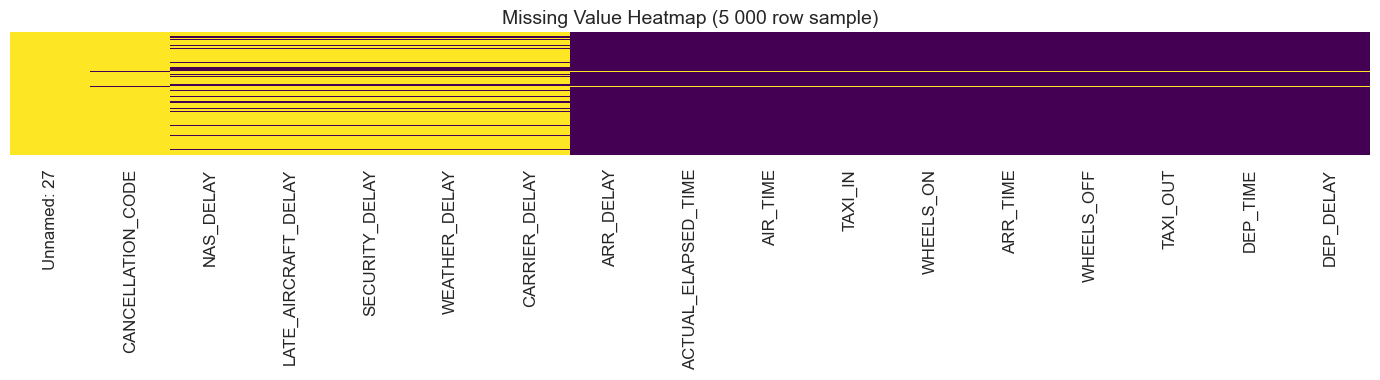

In [4]:
# Missing values overview
missing = df_raw.isnull().sum().sort_values(ascending=False)
missing_pct = (missing / len(df_raw) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0]

print('=== Columns with Missing Values ===')
display(missing_df)

if len(missing_df) > 0:
    fig, ax = plt.subplots(figsize=(14, 4))
    sample_miss = df_raw[missing_df.index].sample(min(5000, len(df_raw)), random_state=RANDOM_STATE)
    sns.heatmap(sample_miss.isnull(), yticklabels=False, cbar=False, cmap='viridis', ax=ax)
    ax.set_title('Missing Value Heatmap (5 000 row sample)', fontsize=14)
    plt.tight_layout()
    plt.show()

---
## 2️⃣ Exploratory Data Analysis (EDA)

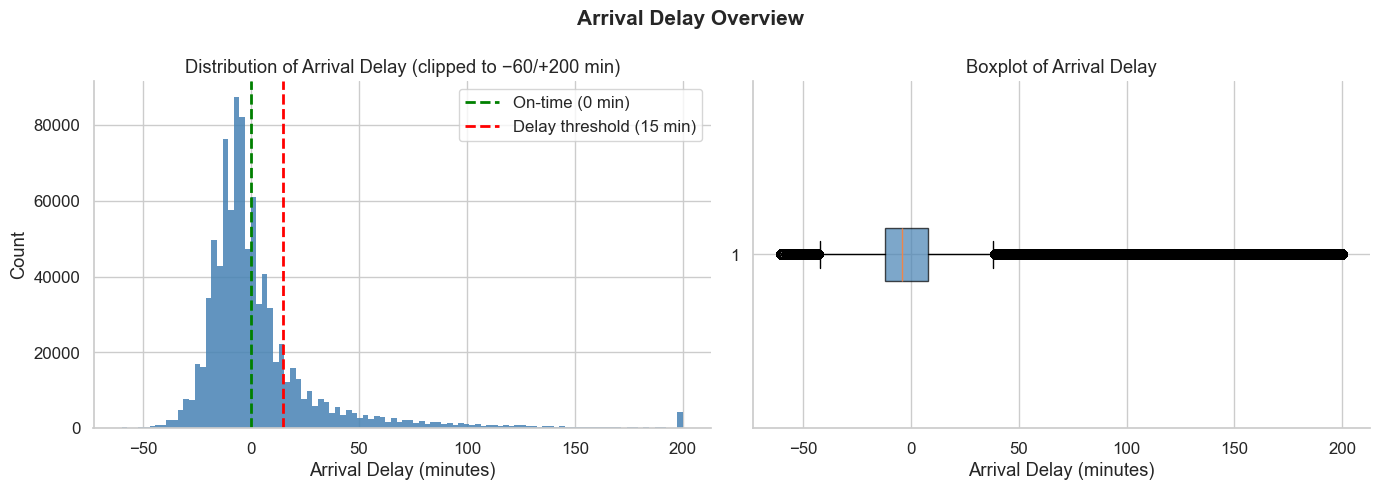

Mean   ARR_DELAY : 4.29 min
Median ARR_DELAY : -4.00 min
Std    ARR_DELAY : 34.77 min
Flights delayed ≥15 min: 167,223 (18.5%)


In [5]:
# ARR_DELAY distribution
arr = df_raw['ARR_DELAY'].dropna()
arr_clipped = arr.clip(-60, 200)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(arr_clipped, bins=100, color='steelblue', edgecolor='none', alpha=0.85)
axes[0].axvline(0,  color='green', lw=2, ls='--', label='On-time (0 min)')
axes[0].axvline(15, color='red',   lw=2, ls='--', label='Delay threshold (15 min)')
axes[0].set_title('Distribution of Arrival Delay (clipped to −60/+200 min)')
axes[0].set_xlabel('Arrival Delay (minutes)')
axes[0].set_ylabel('Count')
axes[0].legend()

axes[1].boxplot(arr_clipped, vert=False, patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.7))
axes[1].set_title('Boxplot of Arrival Delay')
axes[1].set_xlabel('Arrival Delay (minutes)')

plt.suptitle('Arrival Delay Overview', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Mean   ARR_DELAY : {arr.mean():.2f} min')
print(f'Median ARR_DELAY : {arr.median():.2f} min')
print(f'Std    ARR_DELAY : {arr.std():.2f} min')
print(f'Flights delayed ≥15 min: {(arr >= 15).sum():,} ({(arr >= 15).mean()*100:.1f}%)')

=== Delay Statistics by Airline ===


,Avg Delay,Median Delay,Flights
OP_CARRIER,,,
EV,11.592200,0.0,41589
OH,10.312914,0.0,20830
FL,8.319907,-2.0,35601
MQ,6.236991,-3.0,60150
XE,5.864578,-4.0,43272
YV,5.848419,-3.0,33896
AA,5.639078,-4.0,77025
CO,5.336105,-3.0,36194
B6,5.052163,-6.0,27165


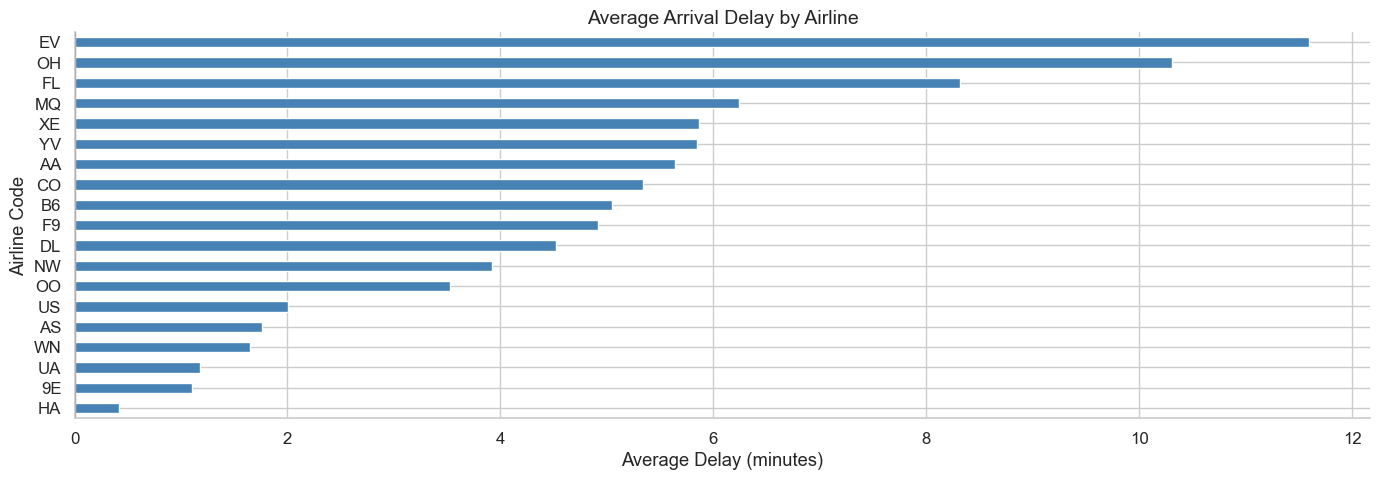

In [6]:
# Delay by Airline
carrier_delay = (
    df_raw.groupby('OP_CARRIER')['ARR_DELAY']
    .agg(['mean', 'median', 'count'])
    .rename(columns={'mean':'Avg Delay', 'median':'Median Delay', 'count':'Flights'})
    .sort_values('Avg Delay', ascending=False)
)
print('=== Delay Statistics by Airline ===')
display(carrier_delay)

fig, ax = plt.subplots(figsize=(14, 5))
carrier_delay['Avg Delay'].sort_values().plot(kind='barh', color='steelblue', ax=ax)
ax.axvline(0, color='black', lw=0.8)
ax.set_title('Average Arrival Delay by Airline', fontsize=14)
ax.set_xlabel('Average Delay (minutes)')
ax.set_ylabel('Airline Code')
plt.tight_layout()
plt.show()

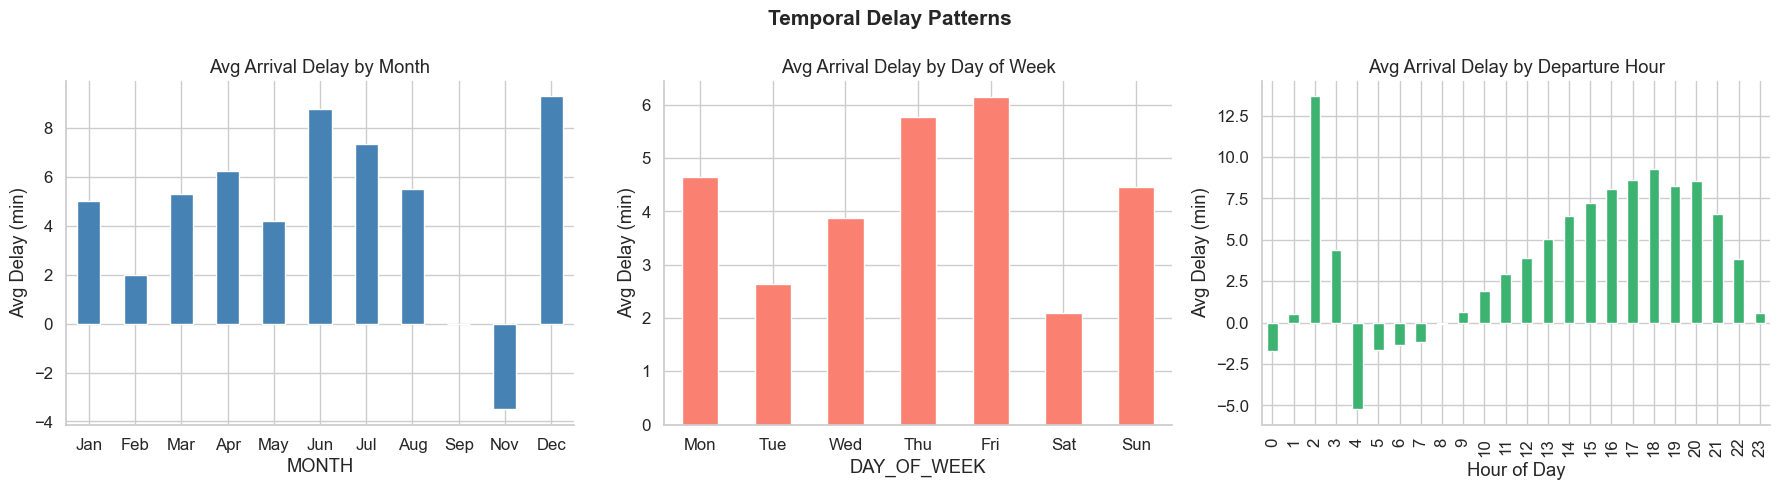

In [7]:
# Temporal patterns – labels derived dynamically from actual data
_all_months = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
_all_dows   = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']

df_raw['FL_DATE']     = pd.to_datetime(df_raw['FL_DATE'], errors='coerce')
df_raw['MONTH']       = df_raw['FL_DATE'].dt.month
df_raw['DAY_OF_WEEK'] = df_raw['FL_DATE'].dt.dayofweek
df_raw['DEP_HOUR']    = (df_raw['CRS_DEP_TIME'] // 100).clip(0, 23)

month_grp = df_raw.groupby('MONTH')['ARR_DELAY'].mean()
dow_grp   = df_raw.groupby('DAY_OF_WEEK')['ARR_DELAY'].mean()
month_labels = [_all_months[m-1] for m in month_grp.index]
dow_labels   = [_all_dows[d]     for d in dow_grp.index]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

month_grp.plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_xticklabels(month_labels, rotation=0)
axes[0].set_title('Avg Arrival Delay by Month')
axes[0].set_ylabel('Avg Delay (min)')

dow_grp.plot(kind='bar', ax=axes[1], color='salmon')
axes[1].set_xticklabels(dow_labels, rotation=0)
axes[1].set_title('Avg Arrival Delay by Day of Week')
axes[1].set_ylabel('Avg Delay (min)')

df_raw.groupby('DEP_HOUR')['ARR_DELAY'].mean().plot(kind='bar', ax=axes[2], color='mediumseagreen')
axes[2].set_title('Avg Arrival Delay by Departure Hour')
axes[2].set_xlabel('Hour of Day')
axes[2].set_ylabel('Avg Delay (min)')

plt.suptitle('Temporal Delay Patterns', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

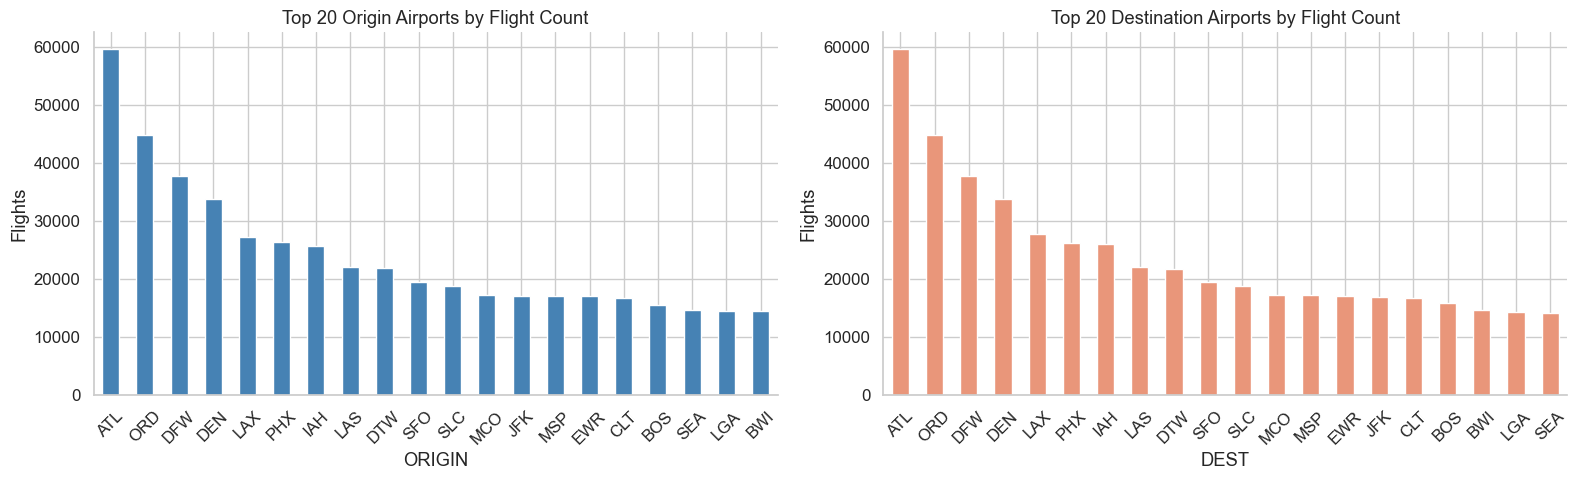

In [8]:
# Top Origin & Destination Airports
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

df_raw['ORIGIN'].value_counts().head(20).plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Top 20 Origin Airports by Flight Count')
axes[0].set_ylabel('Flights')
axes[0].tick_params(axis='x', rotation=45)

df_raw['DEST'].value_counts().head(20).plot(kind='bar', ax=axes[1], color='darksalmon')
axes[1].set_title('Top 20 Destination Airports by Flight Count')
axes[1].set_ylabel('Flights')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

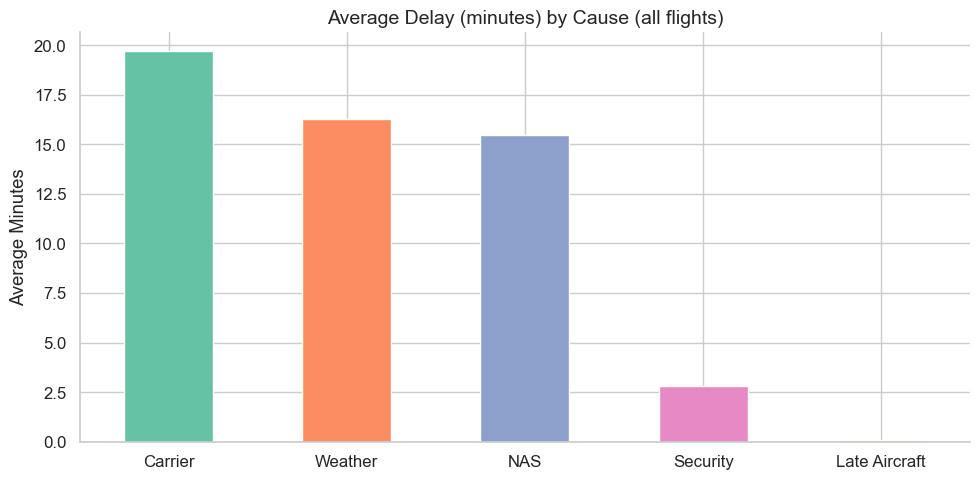

In [9]:
# Delay breakdown by cause
delay_cols = ['CARRIER_DELAY','WEATHER_DELAY','NAS_DELAY','SECURITY_DELAY','LATE_AIRCRAFT_DELAY']
delay_means = df_raw[delay_cols].mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
delay_means.plot(kind='bar', ax=ax, color=sns.color_palette('Set2', len(delay_means)))
ax.set_title('Average Delay (minutes) by Cause (all flights)', fontsize=14)
ax.set_ylabel('Average Minutes')
ax.set_xticklabels(['Carrier','Weather','NAS','Security','Late Aircraft'], rotation=0)
plt.tight_layout()
plt.show()

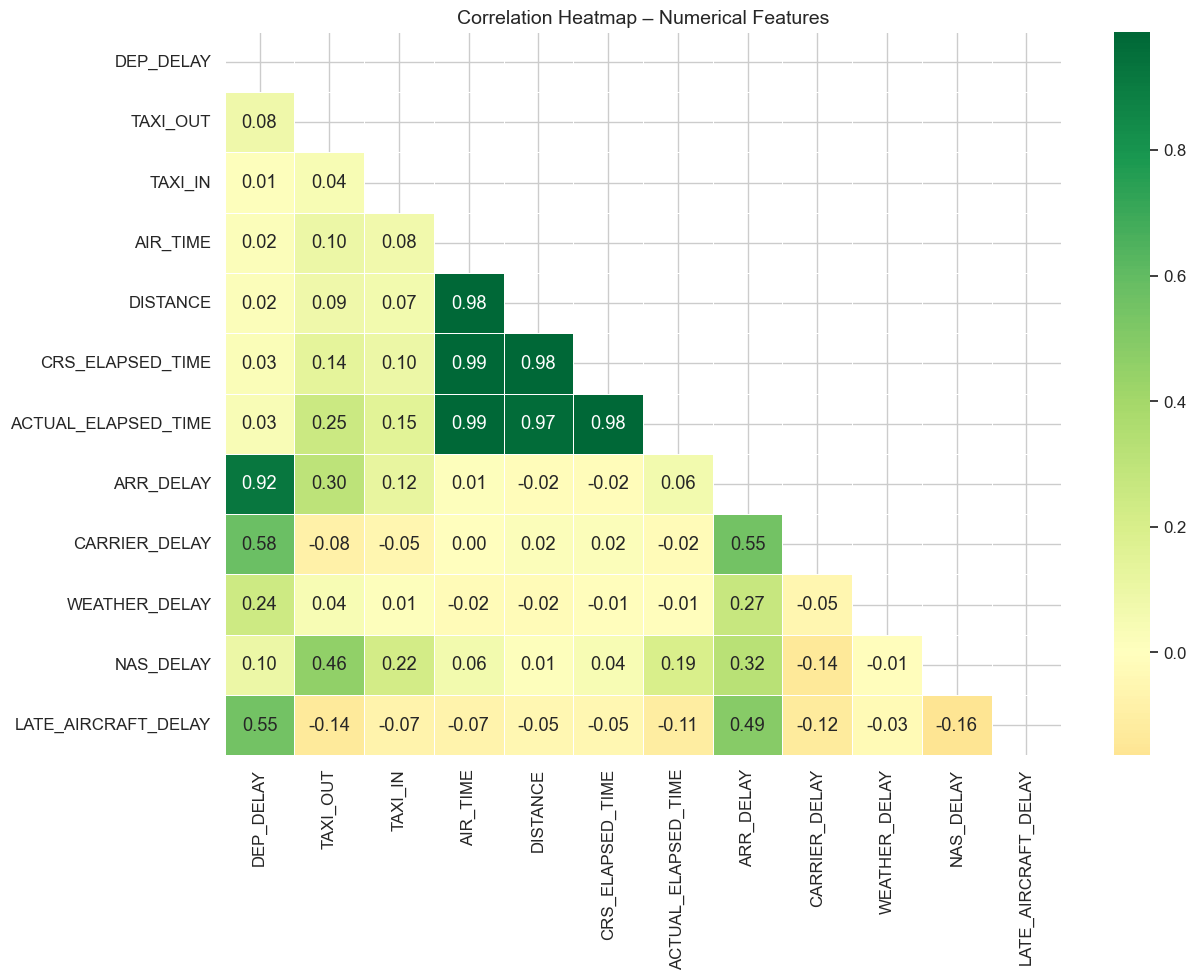

In [10]:
# Correlation Heatmap
num_cols = ['DEP_DELAY','TAXI_OUT','TAXI_IN','AIR_TIME','DISTANCE',
            'CRS_ELAPSED_TIME','ACTUAL_ELAPSED_TIME','ARR_DELAY',
            'CARRIER_DELAY','WEATHER_DELAY','NAS_DELAY','LATE_AIRCRAFT_DELAY']
corr = df_raw[num_cols].corr()

fig, ax = plt.subplots(figsize=(13, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, linewidths=0.5, ax=ax)
ax.set_title('Correlation Heatmap – Numerical Features', fontsize=14)
plt.tight_layout()
plt.show()

---
## 3️⃣ Data Cleaning

In [12]:
df = df_raw.copy()
print(f'Shape before cleaning: {df.shape}')

# Remove cancelled & diverted flights
df = df[df['CANCELLED'] == 0].copy()
print(f'After removing cancelled flights: {df.shape}')
df = df[df['DIVERTED'] == 0].copy()
print(f'After removing diverted flights: {df.shape}')

# Drop columns with leakage or no value
cols_to_drop = [
    'Unnamed: 27', 'CANCELLATION_CODE', 'CANCELLED', 'DIVERTED',
    'DEP_TIME', 'ARR_TIME', 'WHEELS_OFF', 'WHEELS_ON',
    'ACTUAL_ELAPSED_TIME', 'AIR_TIME',
    'CARRIER_DELAY', 'WEATHER_DELAY', 'NAS_DELAY',
    'SECURITY_DELAY', 'LATE_AIRCRAFT_DELAY',
    'OP_CARRIER_FL_NUM',
]
cols_to_drop = [c for c in cols_to_drop if c in df.columns]
df.drop(columns=cols_to_drop, inplace=True)
print(f'After dropping leakage/irrelevant columns: {df.shape}')

# Drop rows missing ARR_DELAY
df.dropna(subset=['ARR_DELAY'], inplace=True)
print(f'After dropping rows with missing ARR_DELAY: {df.shape}')

# Fill remaining numeric NAs with median
num_cols_remaining = df.select_dtypes(include='number').columns.tolist()
df[num_cols_remaining] = df[num_cols_remaining].fillna(df[num_cols_remaining].median())

# Drop duplicates
n_before = len(df)
df.drop_duplicates(inplace=True)
print(f'Removed {n_before - len(df):,} duplicate rows.')

print(f'\n✅ Final clean shape: {df.shape}')
remaining_nulls = df.isnull().sum()[df.isnull().sum() > 0]
if len(remaining_nulls) > 0:
    display(remaining_nulls)
else:
    print('No remaining missing values.')

Shape before cleaning: (918463, 31)
After removing cancelled flights: (906073, 31)
After removing diverted flights: (903966, 31)
After dropping leakage/irrelevant columns: (903966, 15)
After dropping rows with missing ARR_DELAY: (903966, 15)
Removed 10,476 duplicate rows.

✅ Final clean shape: (893490, 15)
No remaining missing values.


---
## 4️⃣ Feature Engineering

Target variable distribution (IS_DELAYED):
  Not delayed (0): 727,609 (81.4%)
  Delayed (1)    : 165,881 (18.6%)


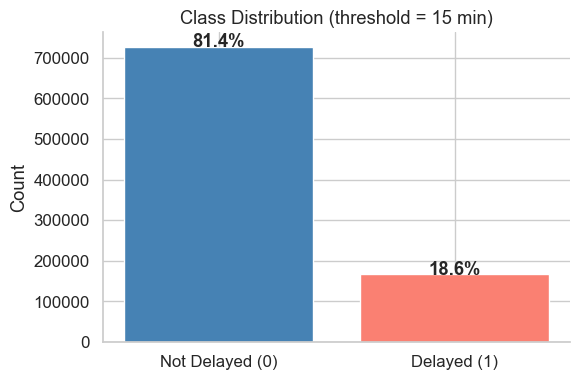

In [13]:
# Binary target variable
DELAY_THRESHOLD = 15
df['IS_DELAYED'] = (df['ARR_DELAY'] >= DELAY_THRESHOLD).astype(int)

vc = df['IS_DELAYED'].value_counts()
print(f'Target variable distribution (IS_DELAYED):')
print(f'  Not delayed (0): {vc[0]:,} ({vc[0]/len(df)*100:.1f}%)')
print(f'  Delayed (1)    : {vc[1]:,} ({vc[1]/len(df)*100:.1f}%)')

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(['Not Delayed (0)', 'Delayed (1)'], [vc[0], vc[1]], color=['steelblue', 'salmon'])
ax.set_title(f'Class Distribution (threshold = {DELAY_THRESHOLD} min)')
ax.set_ylabel('Count')
for i, v in enumerate([vc[0], vc[1]]):
    ax.text(i, v + 200, f'{v/len(df)*100:.1f}%', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

In [14]:
# Time-based features (FL_DATE already parsed in EDA)
df['MONTH']        = df['FL_DATE'].dt.month
df['DAY_OF_WEEK']  = df['FL_DATE'].dt.dayofweek
df['DAY_OF_MONTH'] = df['FL_DATE'].dt.day
df['DEP_HOUR']     = (df['CRS_DEP_TIME'] // 100).clip(0, 23).astype(int)
df['ARR_HOUR']     = (df['CRS_ARR_TIME'] // 100).clip(0, 23).astype(int)
df['IS_WEEKEND']   = (df['DAY_OF_WEEK'] >= 5).astype(int)
df['IS_RUSH_HOUR'] = df['DEP_HOUR'].apply(lambda h: 1 if (6<=h<=9) or (16<=h<=20) else 0)

df.drop(columns=['FL_DATE', 'CRS_DEP_TIME', 'CRS_ARR_TIME'], inplace=True)

print('New features added: MONTH, DAY_OF_WEEK, DAY_OF_MONTH, DEP_HOUR, ARR_HOUR, IS_WEEKEND, IS_RUSH_HOUR')
display(df[['MONTH','DAY_OF_WEEK','DEP_HOUR','IS_WEEKEND','IS_RUSH_HOUR','IS_DELAYED']].head())

New features added: MONTH, DAY_OF_WEEK, DAY_OF_MONTH, DEP_HOUR, ARR_HOUR, IS_WEEKEND, IS_RUSH_HOUR


,MONTH,DAY_OF_WEEK,DEP_HOUR,IS_WEEKEND,IS_RUSH_HOUR,IS_DELAYED
0,1,2,15,0,0,0
1,1,0,6,0,1,0
2,1,4,16,0,1,0
3,1,6,18,1,1,1
4,1,4,8,0,1,0


---
## 5️⃣ Statistical Analysis

In [15]:
print('=== Descriptive Statistics (numerical features) ===')
display(df.describe().T.style.format('{:.2f}'))

=== Descriptive Statistics (numerical features) ===


,count,mean,std,min,25%,50%,75%,max
DEP_DELAY,893490.00,7.60,31.69,-67.00,-5.00,-2.00,5.00,1439.00
TAXI_OUT,893490.00,16.03,10.59,1.00,10.00,13.00,19.00,329.00
TAXI_IN,893490.00,6.89,4.90,1.00,4.00,6.00,8.00,160.00
ARR_DELAY,893490.00,4.34,34.81,-95.00,-12.00,-4.00,8.00,1441.00
CRS_ELAPSED_TIME,893490.00,129.61,69.80,4.00,80.00,111.00,160.00,660.00
DISTANCE,893490.00,727.66,562.41,31.00,326.00,581.00,951.00,4962.00
MONTH,893490.00,6.38,3.34,1.00,4.00,6.00,9.00,12.00
DAY_OF_WEEK,893490.00,2.92,1.99,0.00,1.00,3.00,5.00,6.00
DEP_HOUR,893490.00,12.93,4.57,0.00,9.00,13.00,17.00,23.00
IS_DELAYED,893490.00,0.19,0.39,0.00,0.00,0.00,0.00,1.00


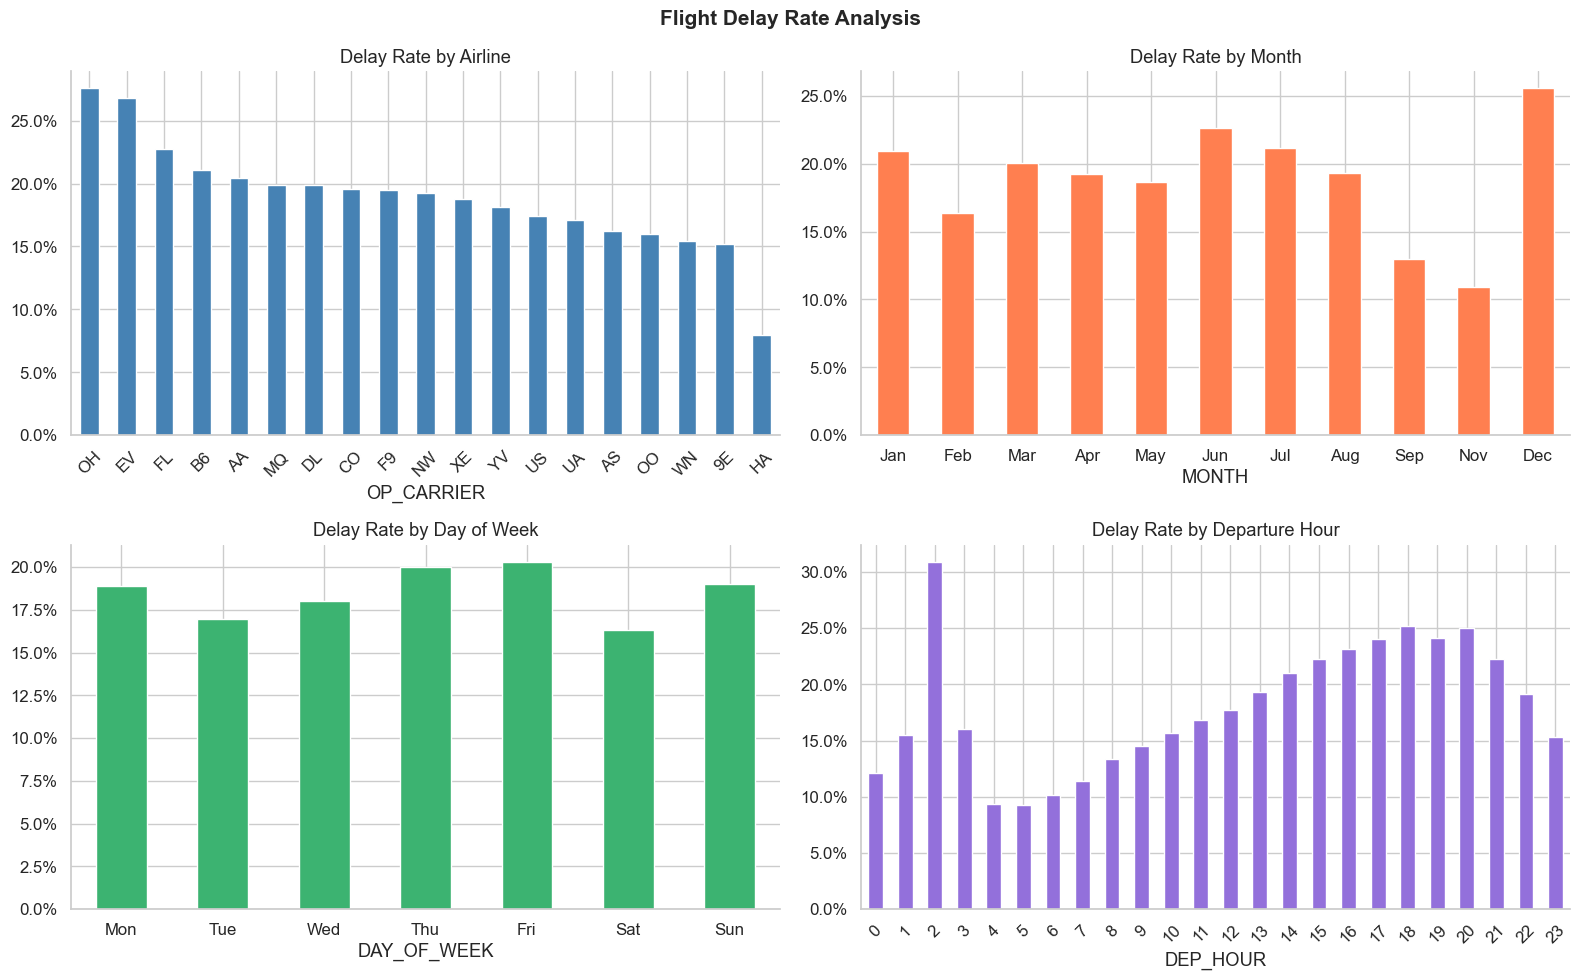

In [16]:
# Delay rate by key dimensions
_all_months2 = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
_all_dows2   = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# By airline
carrier_rate = df.groupby('OP_CARRIER')['IS_DELAYED'].mean().sort_values(ascending=False)
carrier_rate.plot(kind='bar', ax=axes[0,0], color='steelblue')
axes[0,0].yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
axes[0,0].set_title('Delay Rate by Airline')
axes[0,0].tick_params(axis='x', rotation=45)

# By month (dynamic labels)
month_r = df.groupby('MONTH')['IS_DELAYED'].mean()
month_r.plot(kind='bar', ax=axes[0,1], color='coral')
axes[0,1].set_xticklabels([_all_months2[m-1] for m in month_r.index], rotation=0)
axes[0,1].yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
axes[0,1].set_title('Delay Rate by Month')

# By day of week (dynamic labels)
dow_r = df.groupby('DAY_OF_WEEK')['IS_DELAYED'].mean()
dow_r.plot(kind='bar', ax=axes[1,0], color='mediumseagreen')
axes[1,0].set_xticklabels([_all_dows2[d] for d in dow_r.index], rotation=0)
axes[1,0].yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
axes[1,0].set_title('Delay Rate by Day of Week')

# By departure hour
hour_r = df.groupby('DEP_HOUR')['IS_DELAYED'].mean()
hour_r.plot(kind='bar', ax=axes[1,1], color='mediumpurple')
axes[1,1].yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
axes[1,1].set_title('Delay Rate by Departure Hour')
axes[1,1].tick_params(axis='x', rotation=45)

plt.suptitle('Flight Delay Rate Analysis', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

In [17]:
# Hypothesis Tests
print('=== Hypothesis Tests ===')

# T-test: DEP_DELAY
delayed     = df.loc[df['IS_DELAYED']==1, 'DEP_DELAY'].dropna()
not_delayed = df.loc[df['IS_DELAYED']==0, 'DEP_DELAY'].dropna()
t1, p1 = stats.ttest_ind(delayed, not_delayed, equal_var=False)
print(f'\nT-test (DEP_DELAY | delayed vs not delayed):')
print(f'  t={t1:.3f}, p={p1:.2e} → {"Significant" if p1<0.05 else "Not significant"}')
print(f'  Mean DEP_DELAY delayed={delayed.mean():.2f} min, not delayed={not_delayed.mean():.2f} min')

# T-test: DISTANCE
d1 = df.loc[df['IS_DELAYED']==1, 'DISTANCE'].dropna()
d0 = df.loc[df['IS_DELAYED']==0, 'DISTANCE'].dropna()
t2, p2 = stats.ttest_ind(d1, d0, equal_var=False)
print(f'\nT-test (DISTANCE | delayed vs not delayed):')
print(f'  t={t2:.3f}, p={p2:.2e} → {"Significant" if p2<0.05 else "Not significant"}')
print(f'  Mean DISTANCE delayed={d1.mean():.1f} mi, not delayed={d0.mean():.1f} mi')

# Chi-square: IS_WEEKEND
contingency = pd.crosstab(df['IS_WEEKEND'], df['IS_DELAYED'])
chi2, p_chi, dof, _ = stats.chi2_contingency(contingency)
print(f'\nChi-square (IS_WEEKEND vs IS_DELAYED):')
print(f'  chi2={chi2:.3f}, p={p_chi:.2e} → {"Significant" if p_chi<0.05 else "Not significant"}')

=== Hypothesis Tests ===

T-test (DEP_DELAY | delayed vs not delayed):
  t=342.230, p=0.00e+00 → Significant
  Mean DEP_DELAY delayed=46.98 min, not delayed=-1.38 min

T-test (DISTANCE | delayed vs not delayed):
  t=20.440, p=8.85e-93 → Significant
  Mean DISTANCE delayed=753.5 mi, not delayed=721.8 mi

Chi-square (IS_WEEKEND vs IS_DELAYED):
  chi2=126.452, p=2.45e-29 → Significant


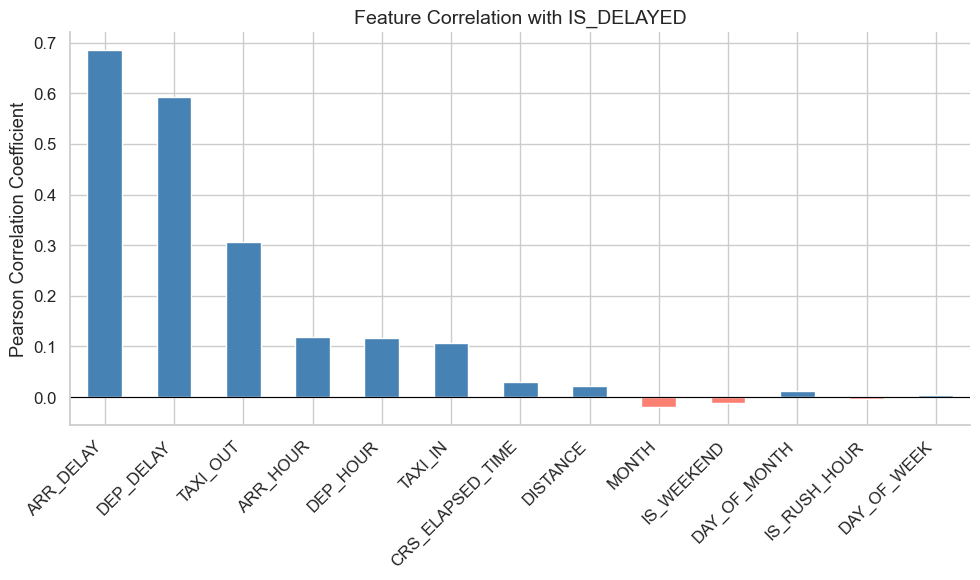


Top 10 features correlated with IS_DELAYED:
ARR_DELAY           0.686049
DEP_DELAY           0.593458
TAXI_OUT            0.306240
ARR_HOUR            0.119347
DEP_HOUR            0.117134
TAXI_IN             0.107241
CRS_ELAPSED_TIME    0.029010
DISTANCE            0.021910
MONTH              -0.019882
IS_WEEKEND         -0.011900
Name: IS_DELAYED, dtype: float64


In [18]:
# Feature-target correlation
feature_corr = df.select_dtypes(include='number').corr()['IS_DELAYED'].drop('IS_DELAYED')
feature_corr = feature_corr.sort_values(key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['steelblue' if v > 0 else 'salmon' for v in feature_corr]
feature_corr.plot(kind='bar', ax=ax, color=colors)
ax.set_title('Feature Correlation with IS_DELAYED', fontsize=14)
ax.set_ylabel('Pearson Correlation Coefficient')
ax.axhline(0, color='black', lw=0.8)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print('\nTop 10 features correlated with IS_DELAYED:')
print(feature_corr.head(10))

---
## 6️⃣ Data Preprocessing & Normalization

In [19]:
# Encode categorical features
cat_cols = ['OP_CARRIER', 'ORIGIN', 'DEST']
label_encoders = {}
for col in cat_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
    label_encoders[col] = le
print('✅ Categorical columns label-encoded:', cat_cols)

# Define feature/target sets
TARGET   = 'IS_DELAYED'
FEATURES = [c for c in df.columns if c not in [TARGET, 'ARR_DELAY']]
X = df[FEATURES]
y = df[TARGET]

print(f'\nFeature set ({len(FEATURES)} features): {FEATURES}')
print(f'\nTarget distribution:')
print(y.value_counts())

✅ Categorical columns label-encoded: ['OP_CARRIER', 'ORIGIN', 'DEST']

Feature set (15 features): ['OP_CARRIER', 'ORIGIN', 'DEST', 'DEP_DELAY', 'TAXI_OUT', 'TAXI_IN', 'CRS_ELAPSED_TIME', 'DISTANCE', 'MONTH', 'DAY_OF_WEEK', 'DEP_HOUR', 'DAY_OF_MONTH', 'ARR_HOUR', 'IS_WEEKEND', 'IS_RUSH_HOUR']

Target distribution:
IS_DELAYED
0    727609
1    165881
Name: count, dtype: int64


In [20]:
# Train / Test split (80/20, stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
print(f'Training set : {X_train.shape[0]:,} rows')
print(f'Test set     : {X_test.shape[0]:,} rows')
print(f'Class balance train: {y_train.mean()*100:.1f}% delayed')
print(f'Class balance test : {y_test.mean()*100:.1f}% delayed')

Training set : 714,792 rows
Test set     : 178,698 rows
Class balance train: 18.6% delayed
Class balance test : 18.6% delayed


✅ Features scaled with StandardScaler.


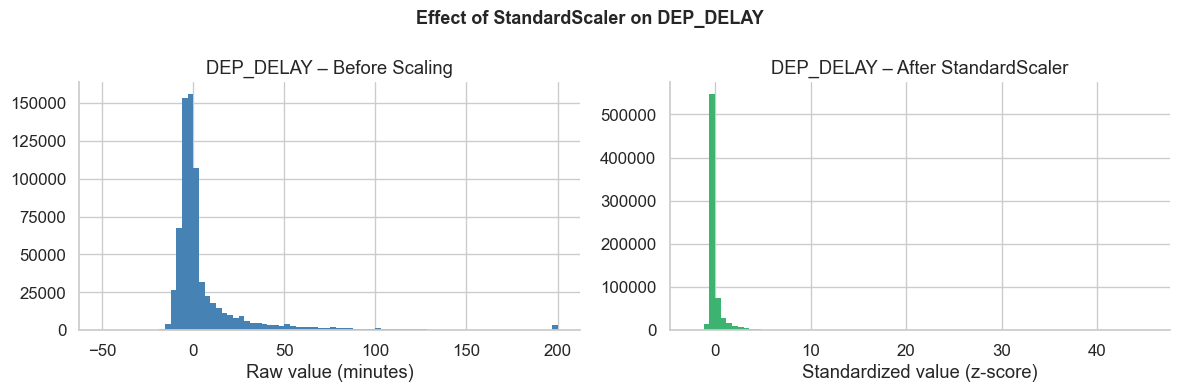

In [21]:
# Feature Scaling (StandardScaler)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)
print('✅ Features scaled with StandardScaler.')

# Visualise effect on DEP_DELAY
dep_delay_idx = list(FEATURES).index('DEP_DELAY') if 'DEP_DELAY' in FEATURES else 0
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(X_train.iloc[:, dep_delay_idx].clip(-50, 200), bins=80, color='steelblue', edgecolor='none')
axes[0].set_title('DEP_DELAY – Before Scaling')
axes[0].set_xlabel('Raw value (minutes)')
axes[1].hist(X_train_scaled[:, dep_delay_idx], bins=80, color='mediumseagreen', edgecolor='none')
axes[1].set_title('DEP_DELAY – After StandardScaler')
axes[1].set_xlabel('Standardized value (z-score)')
plt.suptitle('Effect of StandardScaler on DEP_DELAY', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 7️⃣ Model Training

In [22]:
# Logistic Regression (baseline)
print('Training Logistic Regression...')
lr = LogisticRegression(max_iter=1000, class_weight='balanced',
                         random_state=RANDOM_STATE, n_jobs=-1)
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)
y_prob_lr = lr.predict_proba(X_test_scaled)[:, 1]
print(f'  ROC-AUC = {roc_auc_score(y_test, y_prob_lr):.4f}  ✅')

Training Logistic Regression...
  ROC-AUC = 0.9669  ✅


In [23]:
# Random Forest
print('Training Random Forest (100 trees)...')
rf = RandomForestClassifier(
    n_estimators=100, max_depth=12, min_samples_leaf=20,
    class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1
)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]
print(f'  ROC-AUC = {roc_auc_score(y_test, y_prob_rf):.4f}  ✅')

Training Random Forest (100 trees)...
  ROC-AUC = 0.9680  ✅


In [24]:
# XGBoost (if available)
if XGBOOST_AVAILABLE:
    print('Training XGBoost...')
    scale_pos = (y_train==0).sum() / (y_train==1).sum()
    xgb = XGBClassifier(
        n_estimators=200, max_depth=6, learning_rate=0.1,
        scale_pos_weight=scale_pos,
        eval_metric='logloss',
        random_state=RANDOM_STATE, n_jobs=-1
    )
    xgb.fit(X_train, y_train)
    y_pred_xgb = xgb.predict(X_test)
    y_prob_xgb = xgb.predict_proba(X_test)[:, 1]
    print(f'  ROC-AUC = {roc_auc_score(y_test, y_prob_xgb):.4f}  ✅')
else:
    print('XGBoost not available – skipping.')
    y_pred_xgb = y_prob_xgb = None

Training XGBoost...
  ROC-AUC = 0.9756  ✅


---
## 8️⃣ Model Evaluation

In [25]:
# Classification Reports
models_info = [
    ('Logistic Regression', y_pred_lr, y_prob_lr),
    ('Random Forest',       y_pred_rf, y_prob_rf),
]
if XGBOOST_AVAILABLE and y_pred_xgb is not None:
    models_info.append(('XGBoost', y_pred_xgb, y_prob_xgb))

print('=' * 65)
for name, y_pred, y_prob in models_info:
    auc = roc_auc_score(y_test, y_prob)
    print(f'\n📋 {name}  (ROC-AUC = {auc:.4f})')
    print('-' * 65)
    print(classification_report(y_test, y_pred, target_names=['Not Delayed','Delayed']))
print('=' * 65)


📋 Logistic Regression  (ROC-AUC = 0.9669)
-----------------------------------------------------------------
              precision    recall  f1-score   support

 Not Delayed       0.98      0.93      0.95    145522
     Delayed       0.74      0.90      0.81     33176

    accuracy                           0.92    178698
   macro avg       0.86      0.91      0.88    178698
weighted avg       0.93      0.92      0.92    178698


📋 Random Forest  (ROC-AUC = 0.9680)
-----------------------------------------------------------------
              precision    recall  f1-score   support

 Not Delayed       0.97      0.93      0.95    145522
     Delayed       0.74      0.88      0.81     33176

    accuracy                           0.92    178698
   macro avg       0.86      0.91      0.88    178698
weighted avg       0.93      0.92      0.92    178698


📋 XGBoost  (ROC-AUC = 0.9756)
-----------------------------------------------------------------
              precision    recall  f1

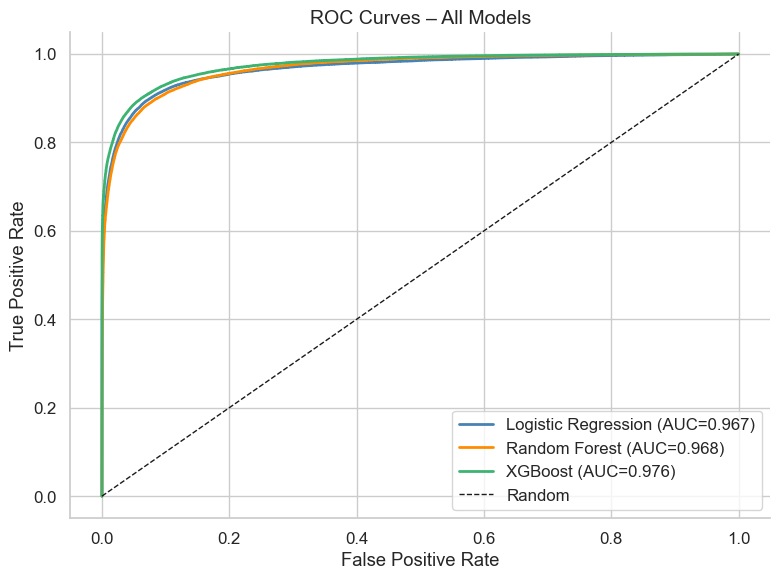

In [26]:
# ROC Curves
fig, ax = plt.subplots(figsize=(8, 6))
for (name, _, y_prob), color in zip(models_info, ['steelblue','darkorange','mediumseagreen']):
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    ax.plot(fpr, tpr, lw=2, color=color, label=f'{name} (AUC={auc:.3f})')
ax.plot([0,1],[0,1], 'k--', lw=1, label='Random')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves – All Models', fontsize=14)
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

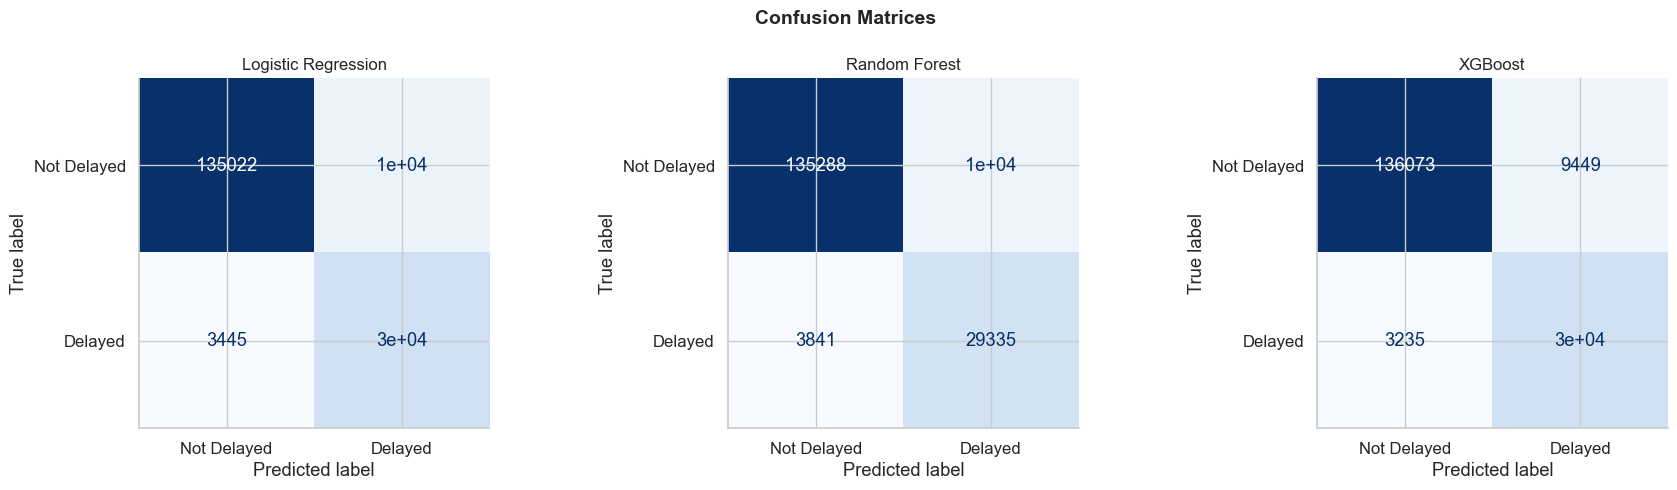

In [27]:
# Confusion Matrices
n_models = len(models_info)
fig, axes = plt.subplots(1, n_models, figsize=(6*n_models, 5))
if n_models == 1:
    axes = [axes]
for ax, (name, y_pred, _) in zip(axes, models_info):
    cm = confusion_matrix(y_test, y_pred)
    ConfusionMatrixDisplay(cm, display_labels=['Not Delayed','Delayed']).plot(
        ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(name, fontsize=12)
plt.suptitle('Confusion Matrices', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

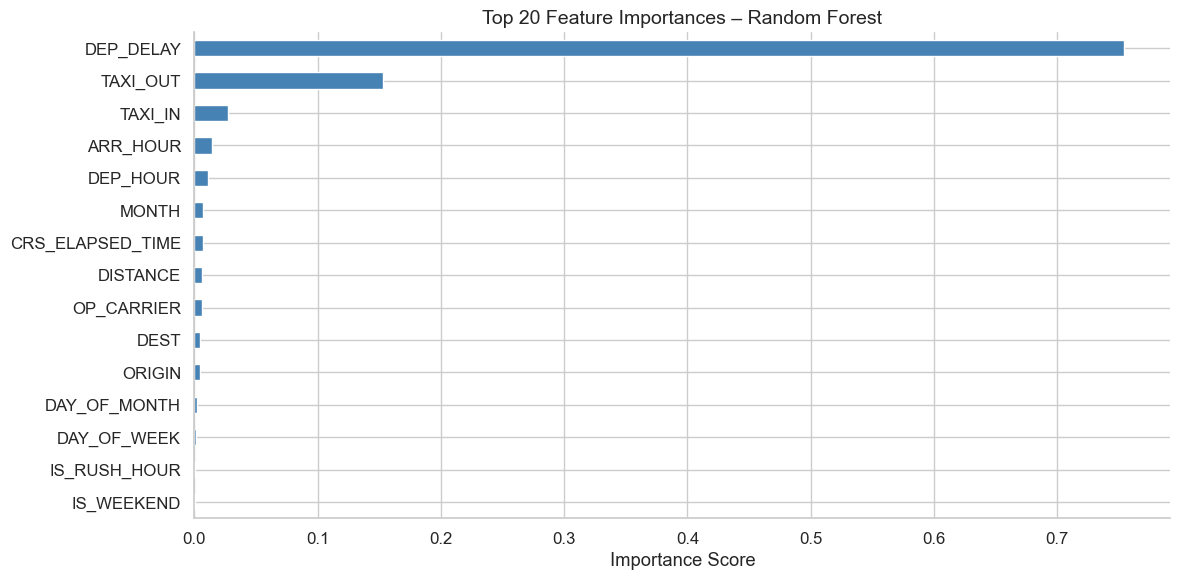

Top 10 features:
DEP_DELAY           0.754046
TAXI_OUT            0.153256
TAXI_IN             0.027463
ARR_HOUR            0.014493
DEP_HOUR            0.011142
MONTH               0.007029
CRS_ELAPSED_TIME    0.006865
DISTANCE            0.006450
OP_CARRIER          0.006007
DEST                0.004403
dtype: float64


In [28]:
# Feature Importance – Random Forest
importances = pd.Series(rf.feature_importances_, index=FEATURES).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12, 6))
importances.head(20).sort_values().plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Top 20 Feature Importances – Random Forest', fontsize=14)
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.show()

print('Top 10 features:')
print(importances.head(10))

In [29]:
# Model Comparison Summary
results = []
for name, y_pred, y_prob in models_info:
    results.append({
        'Model'    : name,
        'Accuracy' : accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, zero_division=0),
        'Recall'   : recall_score(y_test, y_pred, zero_division=0),
        'F1-Score' : f1_score(y_test, y_pred, zero_division=0),
        'ROC-AUC'  : roc_auc_score(y_test, y_prob),
    })

results_df = pd.DataFrame(results).set_index('Model')
print('\n📊 Model Comparison:')
display(results_df.style.format('{:.4f}').highlight_max(axis=0, color='#c6efce'))

best_model = results_df['ROC-AUC'].idxmax()
print(f'\n🏆 Best model by ROC-AUC: {best_model} ({results_df.loc[best_model, "ROC-AUC"]:.4f})')


📊 Model Comparison:


,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Model,,,,,
Logistic Regression,0.9220,0.7390,0.8962,0.8100,0.9669
Random Forest,0.9212,0.7414,0.8842,0.8065,0.9680
XGBoost,0.9290,0.7601,0.9025,0.8252,0.9756



🏆 Best model by ROC-AUC: XGBoost (0.9756)


---
## ✅ Summary

| Step | Description |
|------|-------------|
| **Data Loading** | Sampled ~1M rows from ~7M (chunked reading) |
| **EDA** | Delay distributions, temporal patterns, airline comparisons, correlation heatmap |
| **Cleaning** | Removed cancelled/diverted, dropped leakage columns, filled NAs, removed duplicates |
| **Feature Eng.** | Binary target `IS_DELAYED` (≥15 min), month/DOW/hour features, weekend/rush flags |
| **Statistics** | T-tests, chi-square, feature-target correlation |
| **Preprocessing** | LabelEncoder for categoricals, StandardScaler, 80/20 stratified split |
| **Models** | Logistic Regression, Random Forest, XGBoost |
| **Evaluation** | ROC-AUC, confusion matrix, classification report, feature importance |

> **Key finding:** `DEP_DELAY` is the strongest single predictor of arrival delay, followed by departure hour and route-level factors.